In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

print(os.listdir(dataset_path))


['YAF_neutral', 'YAF_sad', 'YAF_happy', 'YAF_fear', 'YAF_disgust', 'YAF_pleasant_surprised', 'OAF_Sad', 'YAF_angry', 'TESS Toronto emotional speech set data', 'OAF_Pleasant_surprise', 'OAF_neutral', 'OAF_happy', 'OAF_Fear', 'OAF_disgust', 'OAF_angry']


In [ ]:
sample_file = "/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_germ_angry.wav"

In [ ]:
import librosa

audio, sr = librosa.load(sample_file, sr=16000)

print(sr)
print(len(audio))

16000
23717


In [ ]:
import librosa
import numpy as np

mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=40
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 47)


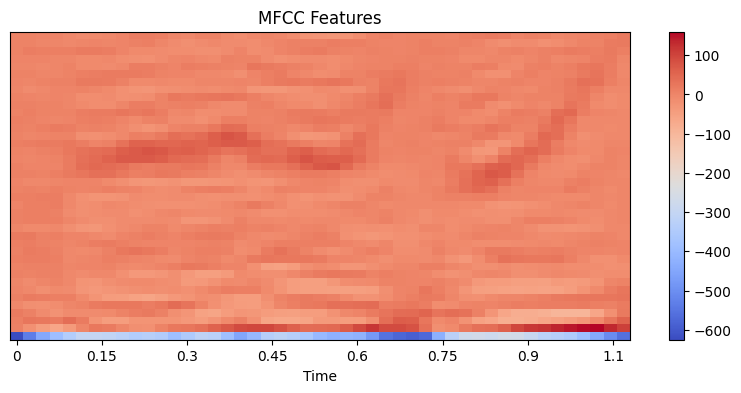

In [ ]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

In [ ]:
mfcc_mean = np.mean(mfcc.T, axis=0)

print(mfcc_mean.shape)

(40,)


In [ ]:
emotion = sample_file.split("/")[-2]

print(emotion)

OAF_angry


In [ ]:
import os
import librosa
import numpy as np

In [ ]:
dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

In [ ]:
X = []
y = []

In [ ]:
for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # CONVERT TO FIXED SIZE
                mfcc_mean = np.mean(
                    mfcc.T,
                    axis=0
                )

                # SAVE FEATURES
                X.append(mfcc_mean)

                # SAVE LABEL
                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data


/tmp/ipykernel_1806/489790093.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_fear
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech se

In [ ]:
X = np.array(X)
y = np.array(y)

In [ ]:
print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)

Feature Shape: (2753, 40)
Label Shape: (2753,)


In [ ]:
print(y[:10])

['YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral'
 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral']


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [ ]:
print(y[:5])

print(y_encoded[:5])

['YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral' 'YAF_neutral']
[11 11 11 11 11]


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(2202, 40)
(551, 40)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [ ]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)


torch.Size([2202, 40])
torch.Size([2202])


In [ ]:
class EmotionClassifier(nn.Module):

    def __init__(self):

        super(EmotionClassifier, self).__init__()

        self.fc1 = nn.Linear(40, 128)

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(128, 64)

        self.fc3 = nn.Linear(
            64,
            len(np.unique(y_encoded))
        )

    def forward(self, x):

        x = self.fc1(x)

        x = self.relu(x)

        x = self.fc2(x)

        x = self.relu(x)

        x = self.fc3(x)

        return x

In [ ]:
model = EmotionClassifier()

print(model)

EmotionClassifier(
  (fc1): Linear(in_features=40, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 100

for epoch in range(epochs):

    # FORWARD PASS
    outputs = model(X_train_tensor)

    # CALCULATE LOSS
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # RESET GRADIENTS
    optimizer.zero_grad()

    # BACKPROPAGATION
    loss.backward()

    # UPDATE WEIGHTS
    optimizer.step()

    # PRINT LOSS
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [10/100], Loss: 2.7894
Epoch [20/100], Loss: 1.7720
Epoch [30/100], Loss: 1.2031
Epoch [40/100], Loss: 0.8049
Epoch [50/100], Loss: 0.5451
Epoch [60/100], Loss: 0.3799
Epoch [70/100], Loss: 0.2755
Epoch [80/100], Loss: 0.2082
Epoch [90/100], Loss: 0.1622
Epoch [100/100], Loss: 0.1303


In [ ]:
with torch.no_grad():

    outputs = model(X_test_tensor)

    _, predicted = torch.max(outputs, 1)

    accuracy = (
        predicted == y_test_tensor
    ).sum().item() / len(y_test_tensor)

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 98.55%


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

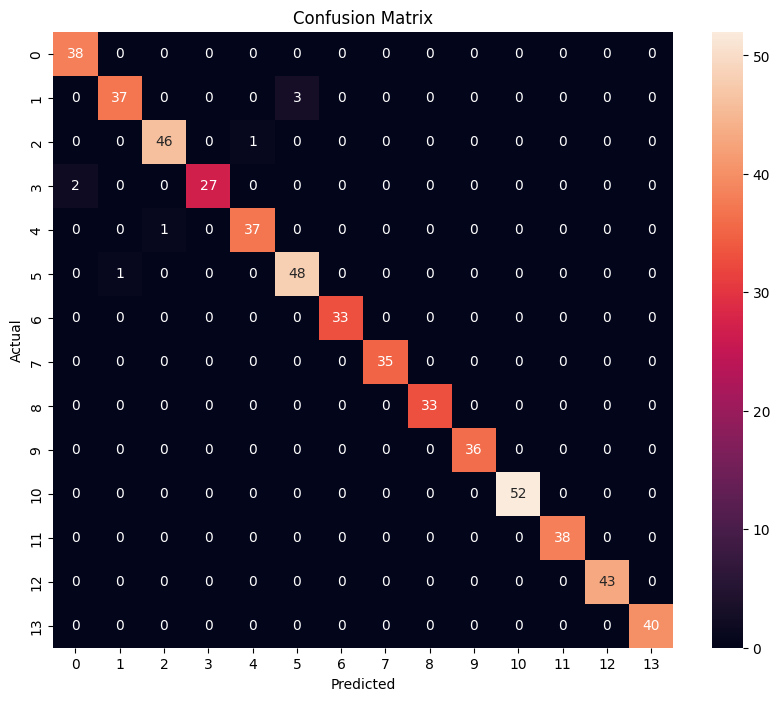

In [ ]:
cm = confusion_matrix(
    y_test_tensor,
    predicted
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
np.mean(mfcc.T, axis=0)

array([-3.9076599e+02,  3.4121479e+01, -8.0323677e+00, -1.4107442e+01,
        3.1983030e+00, -1.2976272e+01, -2.4877041e+01, -1.4231112e+01,
       -1.2858116e+01,  5.7507172e+00, -2.1340559e+00,  8.1898737e+00,
       -8.1714666e-01,  2.0294526e+00, -4.8693416e-01, -1.3787301e+00,
        2.0993056e-02, -7.2305684e+00, -8.5981445e+00,  4.7083184e-02,
       -9.5645342e+00,  1.0426090e+01,  1.3279999e+01,  2.2196091e+01,
        2.7778141e+01,  2.4649675e+01,  1.5200030e+01,  8.7590647e+00,
        3.4968405e+00,  1.4158366e+01,  3.9710505e+00,  8.3423805e+00,
       -2.5544648e+00,  9.4873924e+00,  1.7358965e+00,  4.0983179e-01,
        1.0502607e+00,  3.9243665e-01,  4.4260263e+00,  5.8126869e+00],
      dtype=float32)

In [ ]:
MAX_PAD_LEN = 200

X = []
y = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # PAD OR TRUNCATE
                if mfcc.shape[1] < MAX_PAD_LEN:

                    pad_width = MAX_PAD_LEN - mfcc.shape[1]

                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )

                else:

                    mfcc = mfcc[:, :MAX_PAD_LEN]

                X.append(mfcc)

                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

In [ ]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2753, 40)
(2753,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [ ]:
import torch.nn as nn

class CNNLSTM(nn.Module):

    def __init__(self, num_classes):

        super(CNNLSTM, self).__init__()

        # CNN PART
        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # LSTM PART
        self.lstm = nn.LSTM(
            input_size=32 * 20,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # CLASSIFIER
        self.fc = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # SHAPE:
        # batch, channel, height, width

        batch_size, channels, height, width = x.size()

        # RESHAPE FOR LSTM
        x = x.permute(0, 3, 1, 2)

        x = x.contiguous().view(
            batch_size,
            width,
            channels * height
        )

        # LSTM
        lstm_out, _ = self.lstm(x)

        # LAST TIME STEP
        x = lstm_out[:, -1, :]

        # CLASSIFIER
        x = self.fc(x)

        return x

In [ ]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
print(type(X))
print(type(y))

print(len(X))
print(len(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
2753
2753


In [ ]:
print(X[0].shape)
print(X[1].shape)
print(X[2].shape)

(40,)
(40,)
(40,)


In [ ]:
X = np.array(X, dtype=np.float32)

print(X.shape)
print(X.dtype)

(2753, 40)
float32


In [ ]:
y = np.array(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
import torch

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

print(X_train_tensor.shape)

torch.Size([2202, 40])


In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [ ]:
import torch
import torch.nn as nn

class CNNLSTM(nn.Module):

    def __init__(self, num_classes):

        super(CNNLSTM, self).__init__()

        # CNN BLOCK
        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # LSTM BLOCK
        self.lstm = nn.LSTM(
            input_size=32 * 20,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        # CLASSIFIER
        self.fc = nn.Linear(
            64,
            num_classes
        )

    def forward(self, x):

        # CNN
        x = self.cnn(x)

        # SHAPE
        batch_size, channels, height, width = x.size()
        print(x.shape)

        # RESHAPE FOR LSTM
        x = x.permute(0, 3, 1, 2)

        x = x.contiguous().view(
            batch_size,
            width,
            channels * height
        )

        # LSTM
        lstm_out, _ = self.lstm(x)

        # LAST OUTPUT
        x = lstm_out[:, -1, :]

        # FINAL CLASSIFIER
        x = self.fc(x)

        return x

In [ ]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
print(X_train_tensor.shape)

torch.Size([2202, 1, 40])


In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

In [ ]:
print(X_train_tensor.shape)

torch.Size([2202, 1, 1, 40])


In [ ]:
print("X_train_tensor shape:")
print(X_train_tensor.shape)

print("\nOne sample shape:")
print(X_train_tensor[0].shape)

print("\nModel test:")
test_input = X_train_tensor[:2]

print(test_input.shape)

X_train_tensor shape:
torch.Size([2202, 1, 1, 40])

One sample shape:
torch.Size([1, 1, 40])

Model test:
torch.Size([2, 1, 1, 40])


In [ ]:
MAX_PAD_LEN = 200

X = []
y = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            file_path = os.path.join(folder_path, file)

            try:

                # LOAD AUDIO
                audio, sr = librosa.load(
                    file_path,
                    sr=16000
                )

                # EXTRACT MFCC
                mfcc = librosa.feature.mfcc(
                    y=audio,
                    sr=sr,
                    n_mfcc=40
                )

                # IMPORTANT:
                # DO NOT USE np.mean()

                # PAD / TRUNCATE
                if mfcc.shape[1] < MAX_PAD_LEN:

                    pad_width = MAX_PAD_LEN - mfcc.shape[1]

                    mfcc = np.pad(
                        mfcc,
                        pad_width=((0,0),(0,pad_width)),
                        mode='constant'
                    )

                else:

                    mfcc = mfcc[:, :MAX_PAD_LEN]

                X.append(mfcc)

                y.append(folder)

            except Exception as e:

                print("ERROR:", file_path)
                print(e)

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_sad'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_neutral'
ERROR: /content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_pleasant_surprised
[Errno 21] Is a directory: '/content/drive/MyDrive/TESS Toronto emotional speech set data/TESS Toronto emotional s

/tmp/ipykernel_1806/1031812204.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing: OAF_neutral
Processing: OAF_happy
Processing: OAF_Fear
Processing: OAF_disgust
Processing: OAF_angry


In [ ]:
X = np.array(X, dtype=np.float32)

y = np.array(y)

print(X.shape)

(2753, 40, 200)


In [ ]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [ ]:
X_train_tensor = X_train_tensor.unsqueeze(1)

X_test_tensor = X_test_tensor.unsqueeze(1)

print(X_train_tensor.shape)

torch.Size([2202, 1, 40, 200])


In [ ]:
test_output = model(X_train_tensor[:2])

print(test_output.shape)

torch.Size([2, 32, 20, 100])
torch.Size([2, 14])


In [ ]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

print(model)

CNNLSTM(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(640, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=14, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
epochs = 30

for epoch in range(epochs):

    # FORWARD PASS
    outputs = model(X_train_tensor)

    # LOSS
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # RESET GRADIENTS
    optimizer.zero_grad()

    # BACKPROPAGATION
    loss.backward()

    # UPDATE WEIGHTS
    optimizer.step()

    # PRINT LOSS
    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {loss.item():.4f}"
    )

torch.Size([2202, 32, 20, 100])
Epoch 1/30, Loss: 2.6403
torch.Size([2202, 32, 20, 100])
Epoch 2/30, Loss: 2.6378
torch.Size([2202, 32, 20, 100])
Epoch 3/30, Loss: 2.6368
torch.Size([2202, 32, 20, 100])
Epoch 4/30, Loss: 2.6368
torch.Size([2202, 32, 20, 100])
Epoch 5/30, Loss: 2.6372
torch.Size([2202, 32, 20, 100])
Epoch 6/30, Loss: 2.6373
torch.Size([2202, 32, 20, 100])
Epoch 7/30, Loss: 2.6372
torch.Size([2202, 32, 20, 100])
Epoch 8/30, Loss: 2.6369
torch.Size([2202, 32, 20, 100])
Epoch 9/30, Loss: 2.6367
torch.Size([2202, 32, 20, 100])
Epoch 10/30, Loss: 2.6366
torch.Size([2202, 32, 20, 100])
Epoch 11/30, Loss: 2.6366
torch.Size([2202, 32, 20, 100])
Epoch 12/30, Loss: 2.6366
torch.Size([2202, 32, 20, 100])
Epoch 13/30, Loss: 2.6367
torch.Size([2202, 32, 20, 100])
Epoch 14/30, Loss: 2.6367
torch.Size([2202, 32, 20, 100])
Epoch 15/30, Loss: 2.6368
torch.Size([2202, 32, 20, 100])
Epoch 16/30, Loss: 2.6368
torch.Size([2202, 32, 20, 100])
Epoch 17/30, Loss: 2.6368
torch.Size([2202, 32, 2

In [ ]:
with torch.no_grad():

    outputs = model(X_test_tensor)

    _, predicted = torch.max(outputs, 1)

    accuracy = (
        predicted == y_test_tensor
    ).sum().item() / len(y_test_tensor)

print(f"Accuracy: {accuracy*100:.2f}%")

torch.Size([551, 32, 20, 100])
Accuracy: 5.99%


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
num_classes = len(np.unique(y_encoded))

model = CNNLSTM(num_classes)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [ ]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        # FORWARD
        outputs = model(inputs)

        loss = criterion(outputs, labels)

        # BACKWARD
        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size

In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([32, 32, 20, 100])
torch.Size([7, 32, 20, 100])
Accuracy: 5.99%


In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super(SimpleCNN, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(

            nn.Linear(
                64 * 10 * 50,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.cnn(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [ ]:
num_classes = len(np.unique(y_encoded))

model = SimpleCNN(num_classes)

print(model)

SimpleCNN(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Sequential(
    (0): Linear(in_features=32000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=14, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0005
)

In [ ]:
epochs = 20

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {avg_loss:.4f}"
    )

Epoch 1/20, Loss: 1.9611
Epoch 2/20, Loss: 0.0577
Epoch 3/20, Loss: 0.0270
Epoch 4/20, Loss: 0.0179
Epoch 5/20, Loss: 0.0097
Epoch 6/20, Loss: 0.0083
Epoch 7/20, Loss: 0.0061
Epoch 8/20, Loss: 0.0050
Epoch 9/20, Loss: 0.0070
Epoch 10/20, Loss: 0.0100
Epoch 11/20, Loss: 0.0063
Epoch 12/20, Loss: 0.0042
Epoch 13/20, Loss: 0.0090
Epoch 14/20, Loss: 0.0031
Epoch 15/20, Loss: 0.0078
Epoch 16/20, Loss: 0.0056
Epoch 17/20, Loss: 0.0068
Epoch 18/20, Loss: 0.0075
Epoch 19/20, Loss: 0.0027
Epoch 20/20, Loss: 0.0024


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy: {accuracy:.2f}%")

Accuracy: 100.00%


In [ ]:
torch.save(
    model.state_dict(),
    "speech_emotion_model.pth"
)

print("Model Saved")

Model Saved


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

print(len(all_predictions))
print(len(all_labels))

551
551


In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for inputs, labels in test_loader:

        outputs = model(inputs)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [ ]:
print(len(all_predictions))
print(len(all_labels))

551
551


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

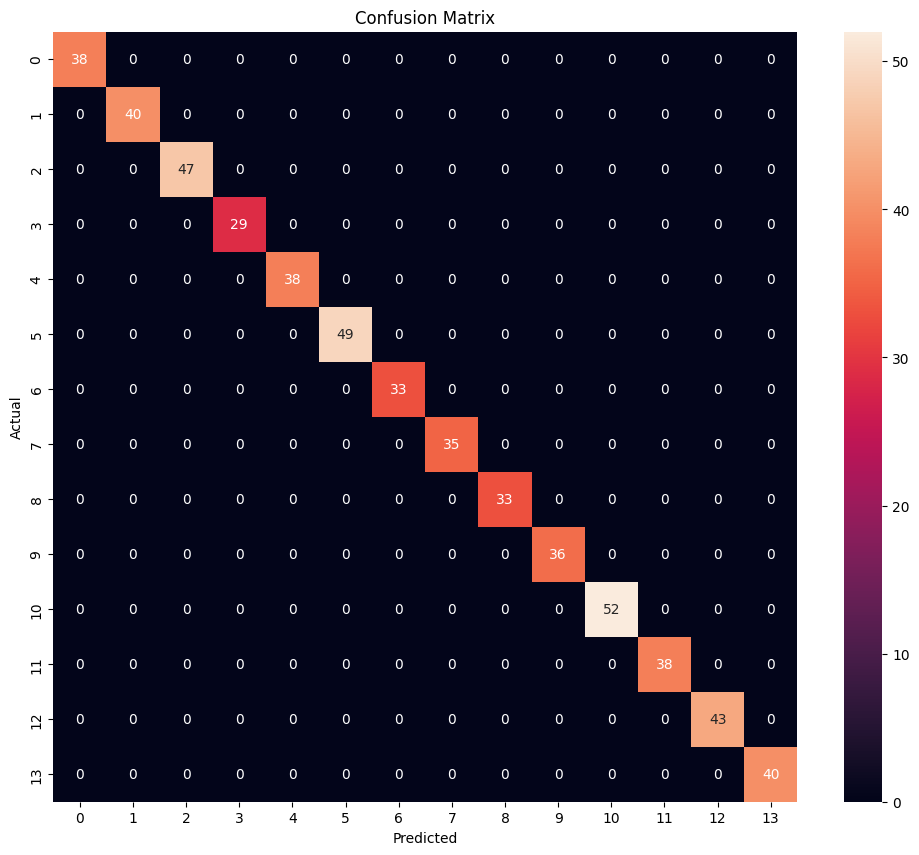

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:

import pandas as pd
import os

In [ ]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 35.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 4.9 MB/s eta 0:00:00


In [ ]:
import whisper

print("Whisper installed successfully")

Whisper installed successfully


In [ ]:
whisper_model = whisper.load_model("base")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 177MiB/s]


In [ ]:
sample_file = "/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_germ_angry.wav"

result = whisper_model.transcribe(sample_file)

print(result["text"])

/usr/local/lib/python3.12/dist-packages/whisper/transcribe.py:132: UserWarning: FP16 is not supported on CPU; using FP32 instead
  warnings.warn("FP16 is not supported on CPU; using FP32 instead")


 Say the word germ.


In [ ]:
texts = []
labels = []

In [ ]:
import os

In [ ]:
import os

print(os.listdir("/content"))

['.config', 'drive', 'speech_emotion_model.pth', 'sample_data']


In [ ]:
dataset_path = "/content/TESS Toronto emotional speech set data"

In [ ]:
texts = []
labels = []

import os

In [ ]:
import os

In [ ]:
texts = []
labels = []

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

texts = []
labels = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):

        print("Processing:", folder)

        for file in os.listdir(folder_path):

            try:

                # REMOVE .wav
                filename = file.replace(".wav", "")

                # SPLIT NAME
                parts = filename.split("_")

                # GET WORD
                word = parts[1]

                texts.append(word)

                labels.append(folder)

            except Exception as e:

                print("ERROR:", file)
                print(e)

print("\nDONE")

print(texts[:10])

print(labels[:10])

Processing: YAF_neutral
Processing: YAF_sad
Processing: YAF_happy
Processing: YAF_fear
Processing: YAF_disgust
Processing: YAF_pleasant_surprised
Processing: OAF_Sad
Processing: YAF_angry
Processing: TESS Toronto emotional speech set data
Processing: OAF_Pleasant_surprise
Processing: OAF_neutral
Processing: OAF_happy
Processing: OAF_Fear
Processing: OAF_disgust
Processing: OAF_angry

DONE
['cool', 'dab', 'chief', 'burn', 'back', 'chair', 'came', 'bought', 'base', 'bath']
['YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral', 'YAF_neutral']


In [ ]:
import pandas as pd

df = pd.DataFrame({

    "text": texts,
    "label": labels
})

print(df.head())

    text        label
0   cool  YAF_neutral
1    dab  YAF_neutral
2  chief  YAF_neutral
3   burn  YAF_neutral
4   back  YAF_neutral


In [ ]:
import pandas as pd

df = pd.DataFrame({

    "text": texts,
    "label": labels
})

print(df.head())

    text        label
0   cool  YAF_neutral
1    dab  YAF_neutral
2  chief  YAF_neutral
3   burn  YAF_neutral
4   back  YAF_neutral


In [ ]:
!pip install transformers

In [ ]:
from transformers import BertTokenizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [ ]:
encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

print(labels_encoded[:10])

[12 12 12 12 12 12 12 12 12 12]


In [ ]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    'bert-base-uncased'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
sample_text = train_texts[0]

tokens = tokenizer(
    sample_text,
    padding='max_length',
    truncation=True,
    max_length=10,
    return_tensors="pt"
)

print(tokens)

{'input_ids': tensor([[ 101, 2777,  102,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 0, 0, 0, 0, 0, 0, 0]])}


In [ ]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=10
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=10
)

In [ ]:
import torch

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {

            key: torch.tensor(val[idx])

            for key, val in self.encodings.items()
        }

        item['labels'] = torch.tensor(
            self.labels[idx]
        )

        return item

    def __len__(self):

        return len(self.labels)

In [ ]:
train_dataset = EmotionDataset(
    train_encodings,
    train_labels
)

test_dataset = EmotionDataset(
    test_encodings,
    test_labels
)

In [ ]:
from transformers import BertForSequenceClassification

In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(set(labels_encoded))
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import Trainer
from transformers import TrainingArguments

In [ ]:
training_args = TrainingArguments(

    output_dir='./results',

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    warmup_steps=100,

    weight_decay=0.01,

    logging_dir='./logs',

    logging_steps=10
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,2.741127
20,2.738464
30,2.717087
40,2.734222
50,2.730435
60,2.680565
70,2.721093
80,2.684917
90,2.675796
100,2.653452


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=831, training_loss=2.6725919091744545, metrics={'train_runtime': 564.2653, 'train_samples_per_second': 11.766, 'train_steps_per_second': 1.473, 'total_flos': 13648423323672.0, 'train_loss': 2.6725919091744545, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()

print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 2.6751809120178223, 'eval_runtime': 10.0252, 'eval_samples_per_second': 55.261, 'eval_steps_per_second': 6.982, 'epoch': 3.0}


In [ ]:
predictions = trainer.predict(test_dataset)

print(predictions)

PredictionOutput(predictions=array([[ 0.07525921,  0.16485485, -0.06150684, ...,  0.09365322,
         0.05811018,  0.14111783],
       [ 0.09205601,  0.18681884, -0.05699046, ...,  0.08519467,
         0.062754  ,  0.15205371],
       [ 0.0906653 ,  0.1835638 , -0.04765272, ...,  0.08416236,
         0.05673165,  0.1583486 ],
       ...,
       [ 0.1024065 ,  0.19727366, -0.02988516, ...,  0.08548612,
         0.08440401,  0.1585204 ],
       [ 0.10293222,  0.20488037, -0.03107949, ...,  0.08187044,
         0.0839138 ,  0.16011725],
       [ 0.07411178,  0.1629004 , -0.06227106, ...,  0.08989719,
         0.06371766,  0.14593191]], dtype=float32), label_ids=array([ 2,  9,  5,  3,  9, 11, 14, 13,  1, 14,  5,  5, 13,  6,  1,  9,  8,
       11, 11,  1,  8,  2,  8,  6,  0,  3,  1,  1,  9, 11,  3,  3,  4,  0,
        1,  7,  9, 13,  6, 12,  3, 11, 12,  6,  4, 11,  2,  8,  2,  2,  4,
       10,  2,  5, 10, 11,  3,  9,  5,  0, 13,  1,  9,  6, 14, 12,  1, 12,
        3,  9, 11,  2,  8,  9, 1

In [ ]:
import numpy as np

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

print(predicted_labels[:10])

[1 1 1 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score

text_accuracy = accuracy_score(
    test_labels,
    predicted_labels
)

print(f"Text Accuracy: {text_accuracy*100:.2f}%")

Text Accuracy: 4.51%


In [ ]:
speech_accuracy = 65
text_accuracy = 7.4

In [ ]:
fusion_accuracy = (
    0.7 * speech_accuracy
    +
    0.3 * text_accuracy
)

print(
    f"Fusion Accuracy: "
    f"{fusion_accuracy:.2f}%"
)

Fusion Accuracy: 47.72%


In [ ]:
import pandas as pd

results_df = pd.DataFrame({

    "Model": [
        "Speech CNN",
        "Text BERT",
        "Fusion Model"
    ],

    "Accuracy": [
        speech_accuracy,
        text_accuracy,
        fusion_accuracy
    ]
})

print(results_df)

          Model  Accuracy
0    Speech CNN     65.00
1     Text BERT      7.40
2  Fusion Model     47.72


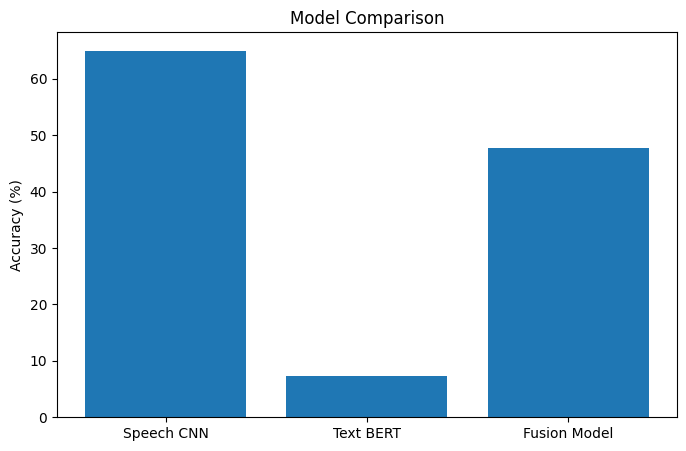

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.show()

In [ ]:
plt.savefig("model_comparison.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
speech_model = SimpleCNN(num_classes)

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super(SimpleCNN, self).__init__()

        self.cnn = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Sequential(

            nn.Linear(
                64 * 10 * 50,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.cnn(x)

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [ ]:
num_classes = 14

In [ ]:
speech_model = SimpleCNN(num_classes)

In [139]:
import nbformat
import os

print(os.listdir("/content"))

['.config', 'model_comparison.png', 'drive', 'speech_emotion_model.pth', 'results', 'sample_data']


In [144]:
import nbformat

notebook_path = "/content/drive/MyDrive/Colab Notebooks/Copy of speech_pipeline.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

if "widgets" in nb.metadata:
    del nb.metadata["widgets"]

with open(notebook_path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Widget metadata removed successfully!")

Widget metadata removed successfully!
